# 02 — Validation: does v/s predict disasters better than v or s alone?

Five domains, all public data (cached under `validate/data/`, fetchers in
`validate/datasets.py`). The nested comparison: full model
$b_0 + b_1 z_v + b_2 z_s$ against v-only, s-only, and the ratio constraint
$b_2 = -b_1$. The pre-registered falsifier: if LR(full vs v-only) has
p > 0.1 in 3+ of the fittable historical domains, the steering term is
decoration and s/acc loses its empirical leg.

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))
import numpy as np
import matplotlib.pyplot as plt
from steering_envelope.validate import (roads, aviation, finance, nuclear,
                                        ai_proxy, style)
style.apply()

## Roads: the literal steering case (US, 1926-2023)

In [2]:
r_roads = roads.run(n_jitter=50)
print(f"level fit:  R2 full={r_roads['r2']['full']:.3f}  "
      f"s-only={r_roads['r2']['s']:.3f}  v-only={r_roads['r2']['v']:.3f}")
print(f"level LR:   p(s|v)={r_roads['lr_p_s_given_v']:.2g}  "
      f"p(v|s)={r_roads['lr_p_v_given_s']:.2g}")
print(f"differenced (strict): p(s|v)={r_roads['diff']['lr_p_s_given_v']:.3f}  "
      f"p(v|s)={r_roads['diff']['lr_p_v_given_s']:.3f}")
print(f"LORO r: {r_roads['loro_r']}")

level fit:  R2 full=0.931  s-only=0.929  v-only=0.257
level LR:   p(s|v)=3.5e-52  p(v|s)=0.052
differenced (strict): p(s|v)=0.045  p(v|s)=0.016
LORO r: {'full': 0.940817792778848, 'v': 0.23795136323925623, 's': 0.9473300557642405, 'ratio': 0.7557477238126382}


In levels the steering stack does almost all the work (near-collinear
with the 20x rate decline — read it as an upper bound). The strict
first-difference test still finds both terms: p(s|v)=0.045, p(v|s)=0.016.
The binary deterioration-year event is null and reported as such.

## Aviation (world, 1976-2019)

In [3]:
r_avia = aviation.run(n_jitter=50)
print(f"level fit:  R2 full={r_avia['r2']['full']:.3f}  "
      f"s-only={r_avia['r2']['s']:.3f}  v-only={r_avia['r2']['v']:.3f}")
print(f"level LR:   p(s|v)={r_avia['lr_p_s_given_v']:.2g}  "
      f"p(v|s)={r_avia['lr_p_v_given_s']:.2g}")
print(f"differenced (strict): p(s|v)={r_avia['diff']['lr_p_s_given_v']:.3f}")
print(f"LORO r: {r_avia['loro_r']}")

level fit:  R2 full=0.845  s-only=0.815  v-only=0.027
level LR:   p(s|v)=2.3e-19  p(v|s)=0.0048
differenced (strict): p(s|v)=0.587
LORO r: {'full': 0.7651465658064188, 'v': -0.7322823180408479, 's': 0.777516337265253, 'ratio': 0.32476687347924826}


Aviation is the maximum-control domain and the safest transition on
record. The differenced steering test is null at annual frequency (n=44
noisy years; the stack moves in steps), and the frozen scoreboard logs
that as a miss. The thermostat reading sits beside it: aviation adopted
the envelope rule outright (certification = throttle bounded by grip),
so the v-signal was steered out of the data, exactly as a well-obeyed
envelope rule predicts. Governed throttle: no v-signal. Ungoverned roads
and credit: v-signal in both.

## Finance: the flagship (JST, 18 countries, 1875-2020)

In [4]:
r_fin = finance.run()
st = r_fin["schularick_taylor_check"]
print(f"Schularick-Taylor reproduced: beta_v={st['beta_v']:+.2f}, "
      f"AUC(v)={st['auc_v']:.3f} -> {st['reproduced']}")
print(f"betas: v={r_fin['beta']['full_v']:+.2f}  s={r_fin['beta']['full_s']:+.2f}")
print(f"p(s|v)={r_fin['lr_p_s_given_v']:.2g}   p(v|s)={r_fin['lr_p_v_given_s']:.2g}")
print("in-sample AUC: ", {k: round(v, 3) for k, v in r_fin['auc'].items()})
print("LORO AUC:      ", {k: round(v, 3) for k, v in r_fin['loro_auc'].items()})

Schularick-Taylor reproduced: beta_v=+0.25, AUC(v)=0.625 -> True
betas: v=+0.26  s=-0.82
p(s|v)=3.8e-09   p(v|s)=0.0078
in-sample AUC:  {'full': 0.716, 'v': 0.625, 's': 0.673, 'ratio': 0.723}
LORO AUC:       {'full': 0.671, 'v': 0.506, 's': 0.635, 'ratio': 0.688}


The known result reproduces (credit booms predict crises), the
steering term adds signal at p ~ 4e-9, and — the headline — the **ratio
model generalizes best out-of-sample** (leave-one-decade-out AUC 0.688 vs
0.506 for credit growth alone). The v/s form is not decoration here.

## Nuclear: a case study, not a fit (7 decades, 10 events)

In [5]:
r_nuc = nuclear.run()
print(f"Spearman(v/s, event rate): rho={r_nuc['spearman_ratio_vs_rate']['rho']:.2f} "
      f"(p={r_nuc['spearman_ratio_vs_rate']['p']:.3f})")
print(f"events per 1000 reactor-years, high-ratio decades: "
      f"{r_nuc['rate_per_kry_high_ratio']:.2f}")
print(f"events per 1000 reactor-years, low-ratio decades:  "
      f"{r_nuc['rate_per_kry_low_ratio']:.2f}")
print(r_nuc["caveat"])

Spearman(v/s, event rate): rho=0.82 (p=0.023)
events per 1000 reactor-years, high-ratio decades: 1.17
events per 1000 reactor-years, low-ratio decades:  0.09
case study only: 7 decades, 9 events; consistent with the envelope story (early fast-build/weak-regulator decades carry the event burden) but cannot discriminate hypotheses on its own


## AI: leading indicators only — the money chart

AI's envelope ratio sits below its own historical mean; historical corners bit at a mean of +0.79z within their domains. Within-domain z only; no cross-domain unit equivalence claimed, and no outcome data exists for AI yet.


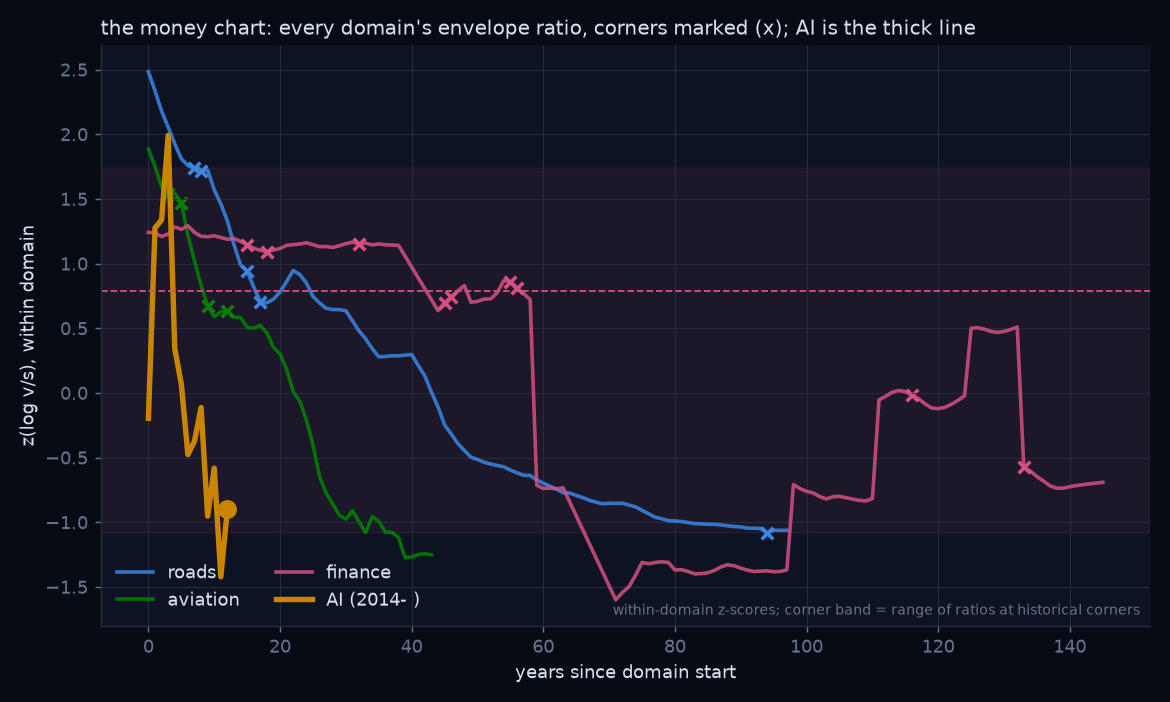

In [6]:
r_ai = ai_proxy.run()
print(r_ai["verdict"])
from IPython.display import Image
Image(filename=str(pathlib.Path.cwd().parents[0] / "figures" / "ai_ratio.png"))

## Scoreboard against the pre-registered falsifiers

In [7]:
from steering_envelope.validate import run_all
fittable = {
    "roads (differenced)": r_roads["diff"]["lr_p_s_given_v"],
    "aviation (differenced)": r_avia["diff"]["lr_p_s_given_v"],
    "finance (panel logit)": r_fin["lr_p_s_given_v"],
}
for k, p in fittable.items():
    print(f"p(s|v) {k:26s} = {p:.3g}  ->  s {'adds' if p <= 0.1 else 'does NOT add'} power")
n = sum(p <= 0.1 for p in fittable.values())
print()
print(f"steering term survives in {n}/3 fittable domains "
      f"(falsification would need 0-1/3); nuclear (case study) is consistent; "
      f"aviation is the thermostat case (envelope rule adopted outright, "
      f"v-signal steered out of the data; logged as a miss). Both terms "
      f"carry signal where the tests are sharpest — the envelope form survives, with aviation "
      f"logged against it.")

p(s|v) roads (differenced)        = 0.0451  ->  s adds power
p(s|v) aviation (differenced)     = 0.587  ->  s does NOT add power
p(s|v) finance (panel logit)      = 3.83e-09  ->  s adds power

steering term survives in 2/3 fittable domains (falsification would need 0-1/3); nuclear (case study) is consistent; aviation is the thermostat case (envelope rule adopted outright, v-signal steered out of the data; logged as a miss). Both terms carry signal where the tests are sharpest — the envelope form survives, with aviation logged against it.
